In [1]:
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as w
from IPython.display import display, clear_output
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
from helpers.df_ops import prepare_df

MWD_DIR   = PROJECT_ROOT / 'Data' / 'mwd'
SAVE_PATH = Path('labels.json')
TOL       = 6

data_files = sorted(MWD_DIR.glob('*.txt'))
all_labels = json.loads(SAVE_PATH.read_text()) if SAVE_PATH.exists() else {}
for f in data_files:
    all_labels.setdefault(f.name, {'maxima': [], 'minima': [], 'const': False, 'bad': False})

print(f'Found {len(data_files)} files in {MWD_DIR}')

Found 1907 files in C:\Users\Joey\Desktop\Cambridge\Work\Thesis\Data\mwd


In [2]:
def load_file(fpath):
    raw = pd.read_csv(fpath, sep=r'\s+', skip_blank_lines=True)
    try:    df = prepare_df(raw, add_prefix=False, relative=True)
    except: df = prepare_df(raw, add_prefix=True,  relative=True)
    df = df.copy()
    df['day'] -= df['day'].min()
    med = df['sind'].median()
    mad = (df['sind'] - med).abs().median()
    return df[(df['sind'] - med).abs() < TOL * mad].sort_values('day').reset_index(drop=True)

def gauss_smooth(t, y, sigma, n=500):
    t_e = np.linspace(t.min(), t.max(), n)
    wt  = np.exp(-0.5 * ((t[:, None] - t_e[None, :]) / sigma) ** 2)
    return t_e, (wt * y[:, None]).sum(0) / wt.sum(0)

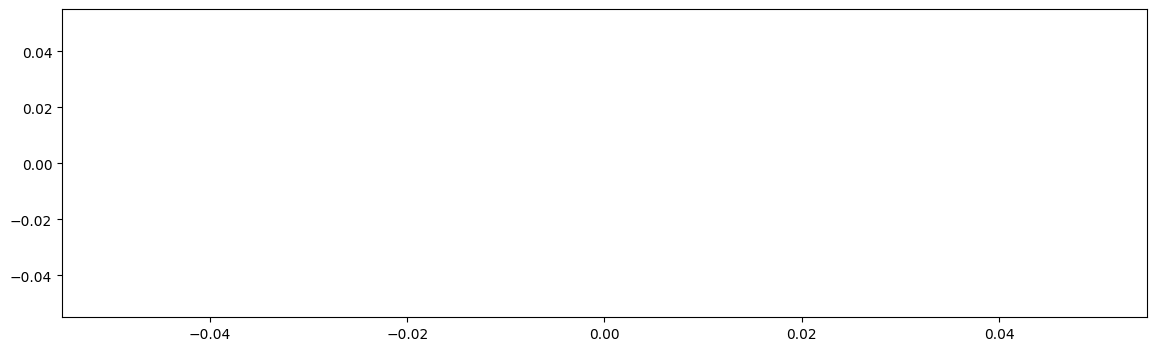

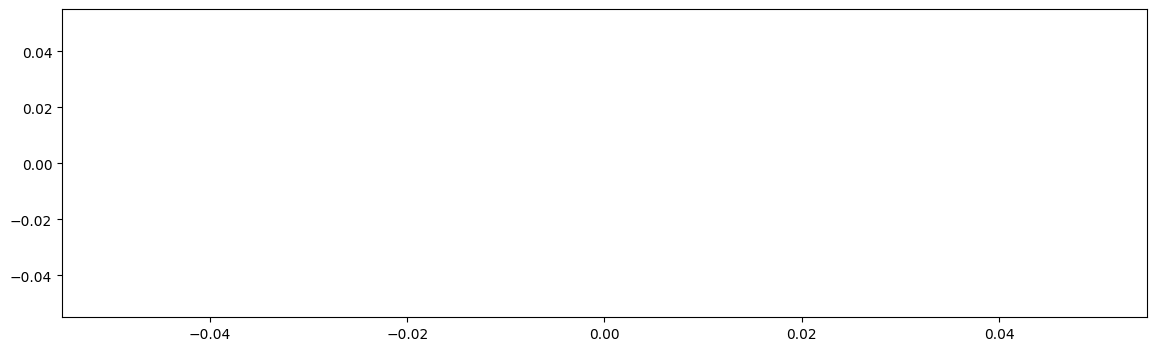

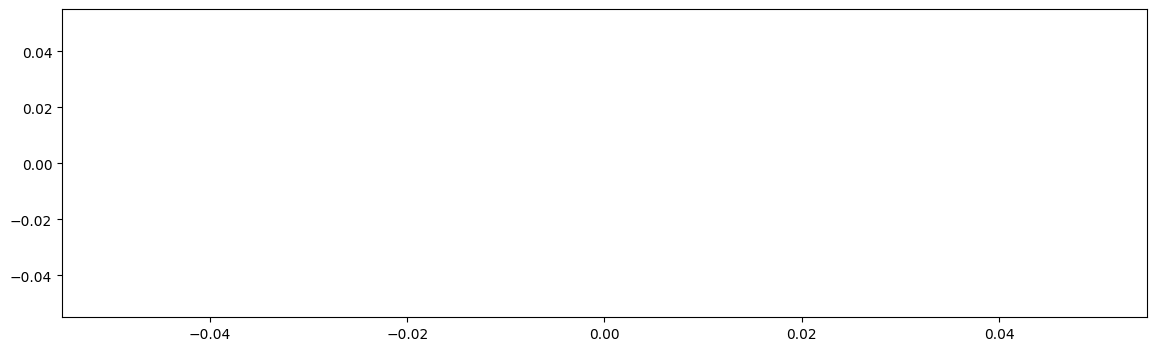

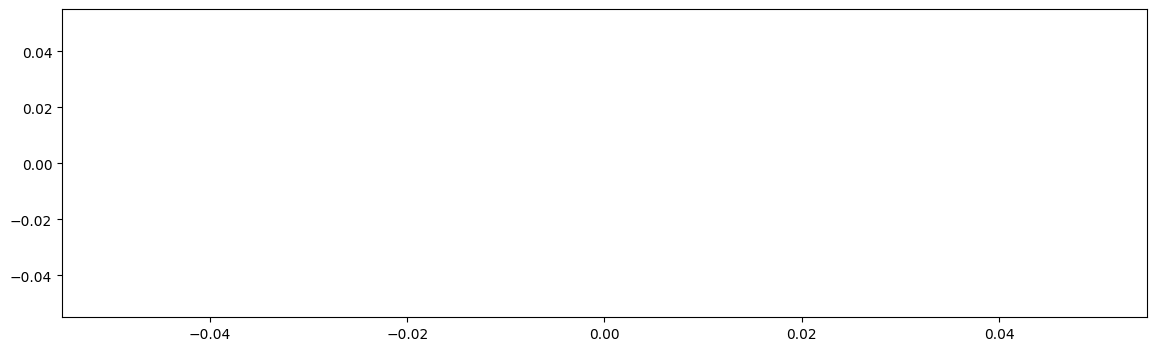

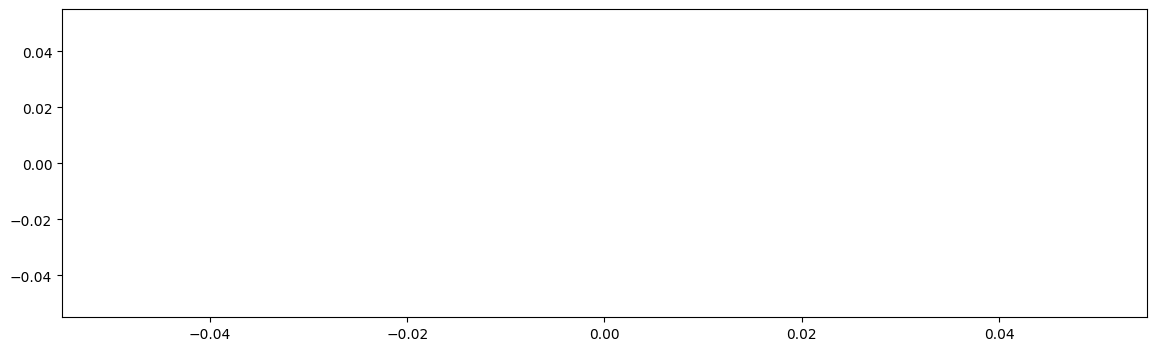

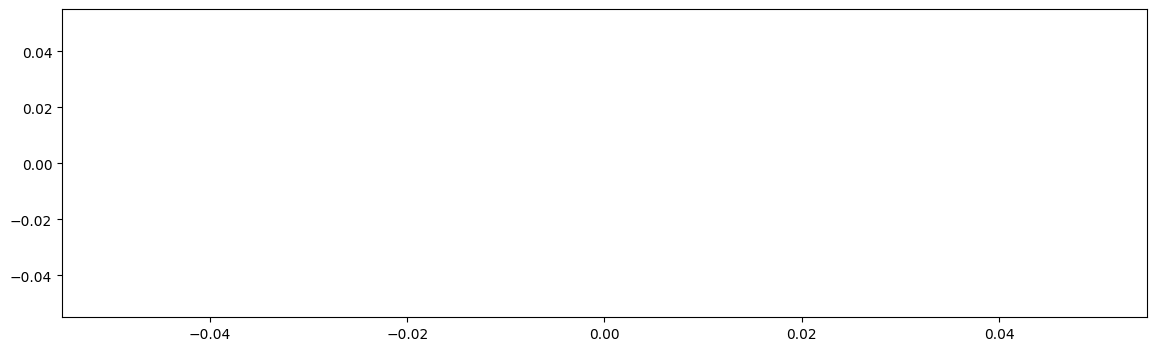

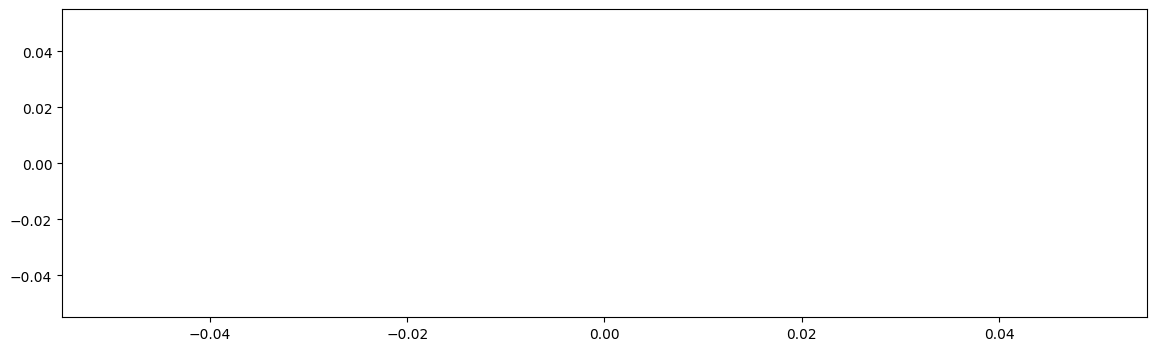

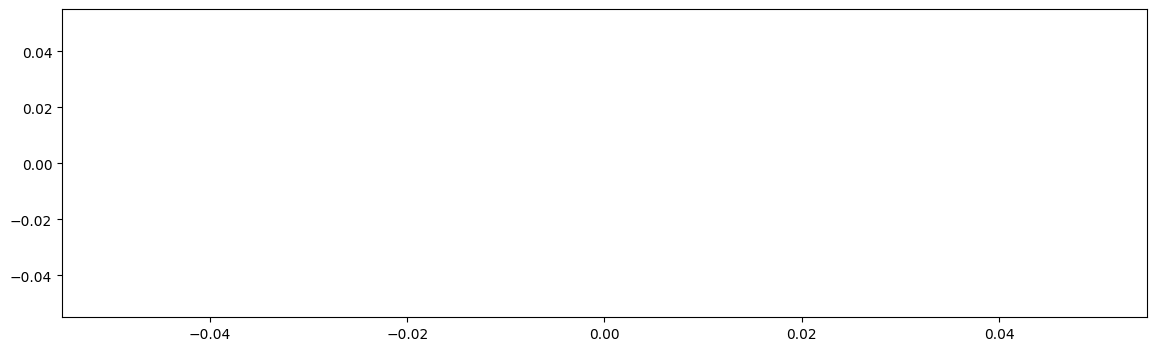

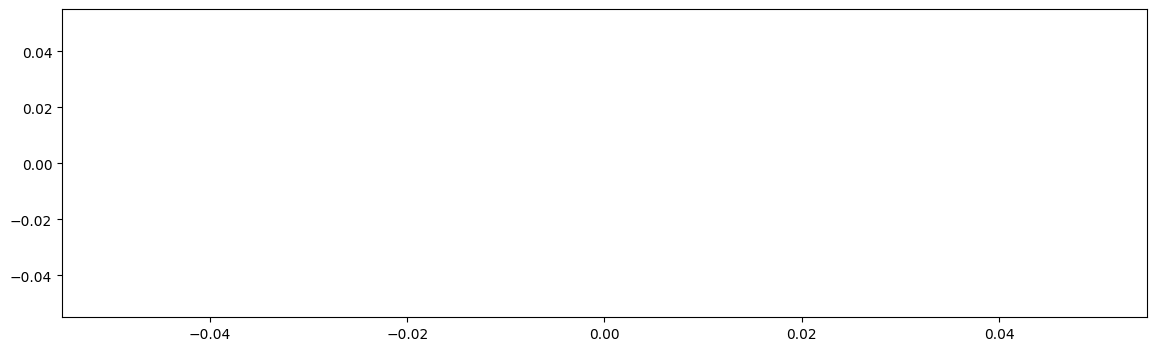

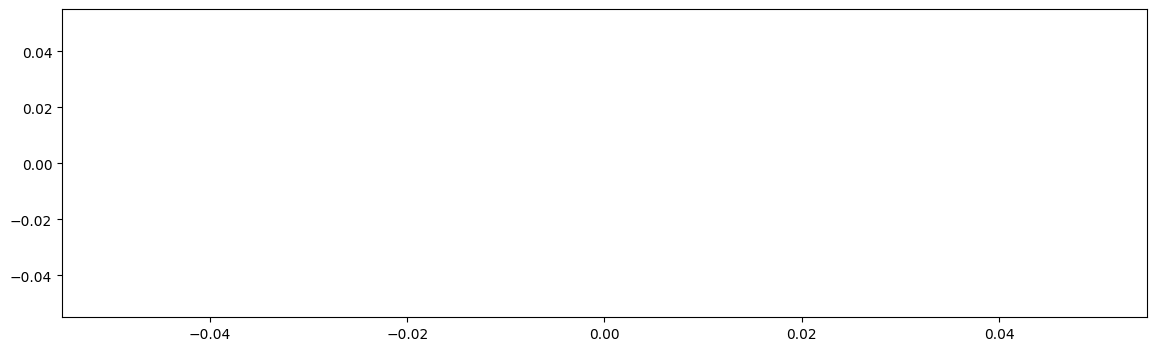

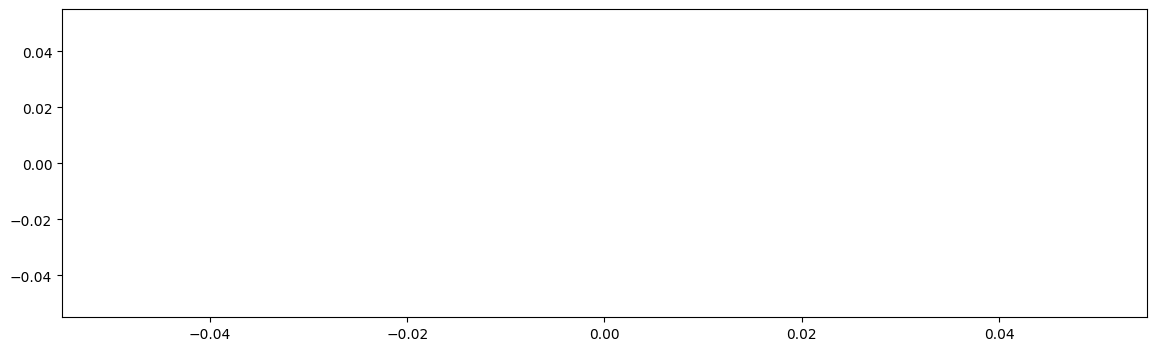

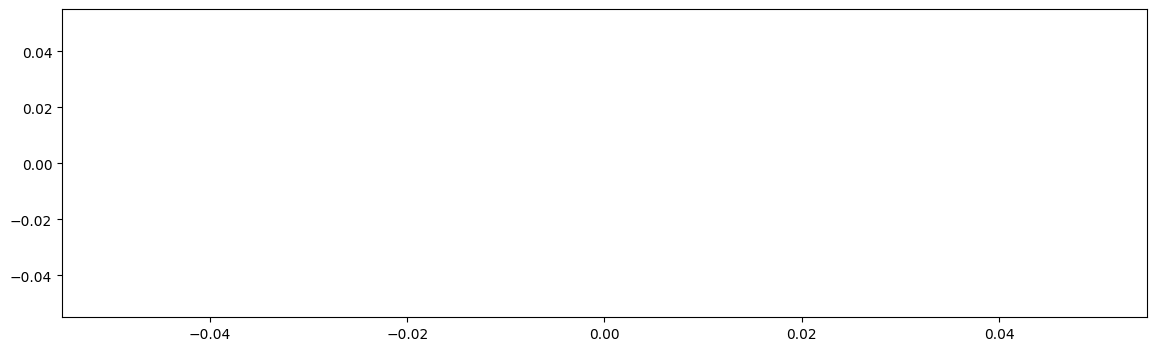

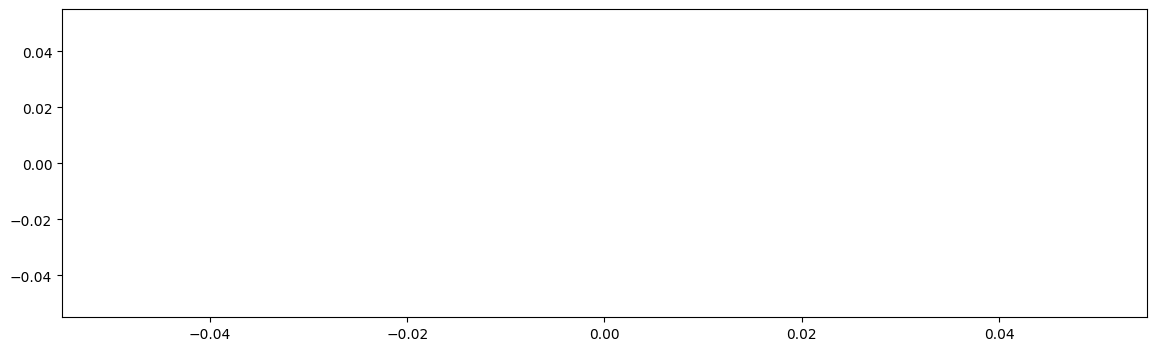

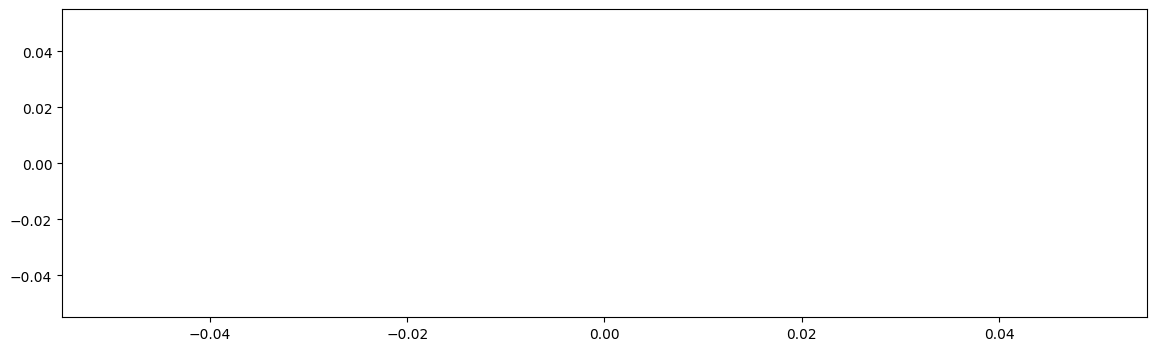

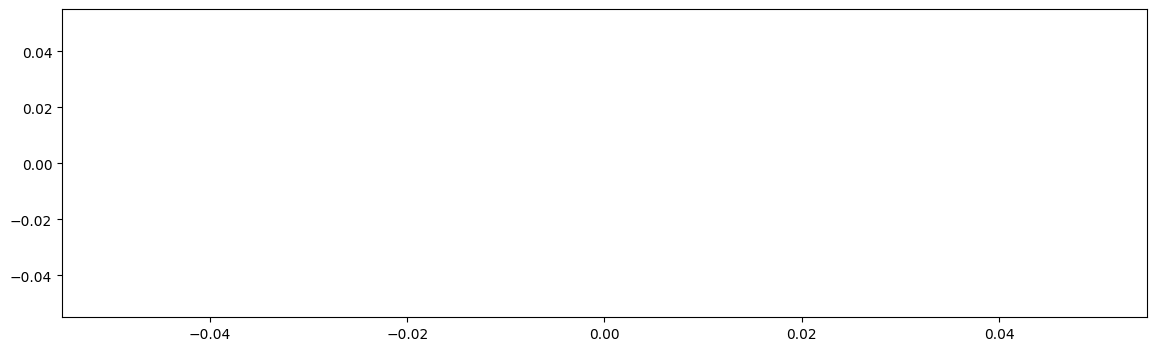

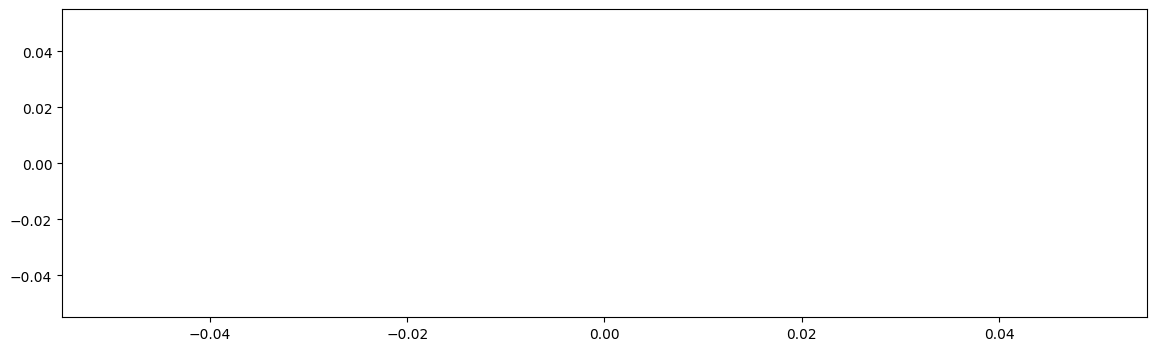

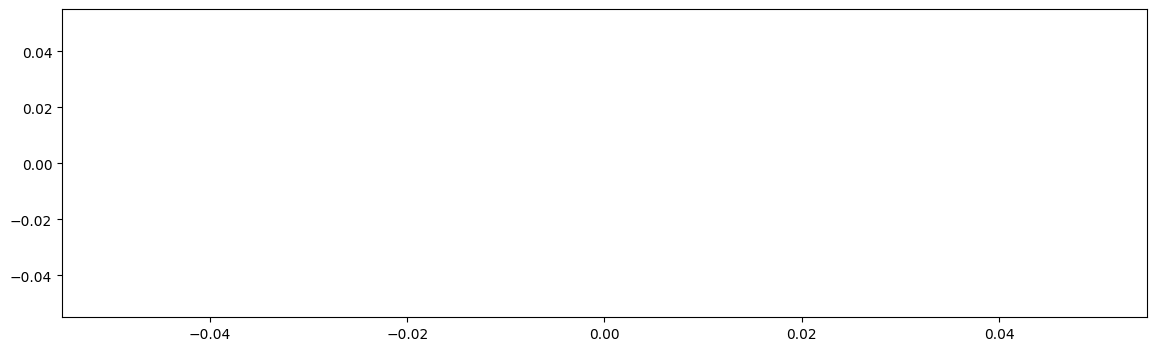

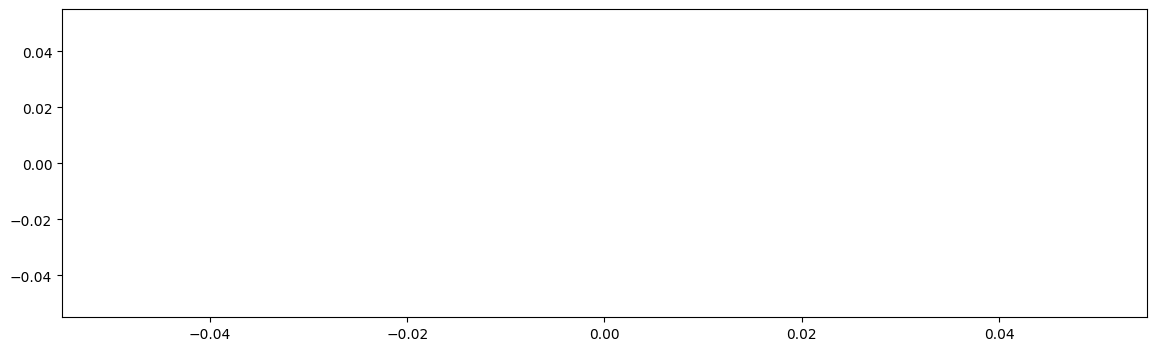

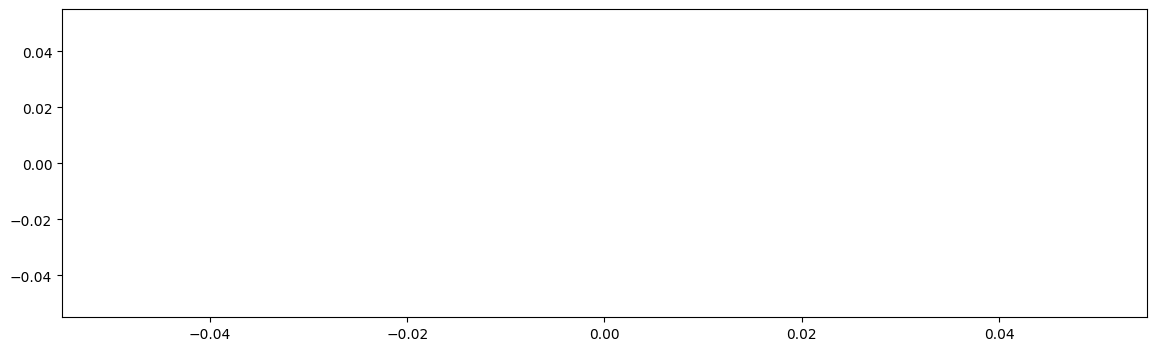

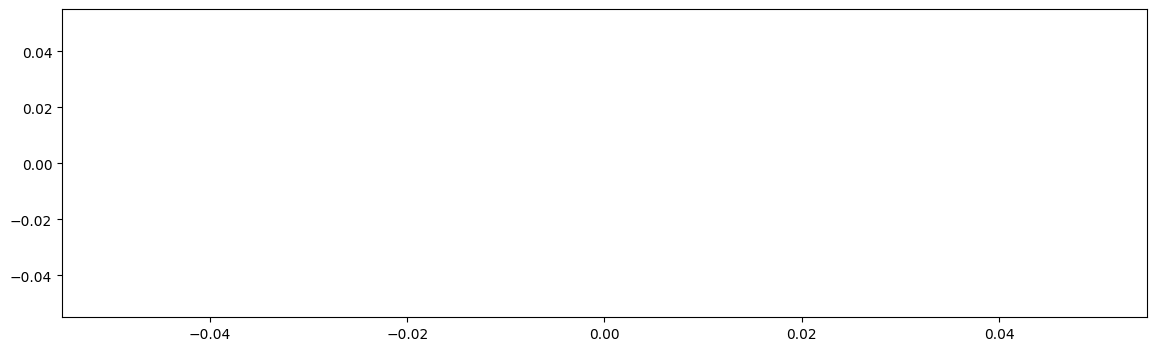

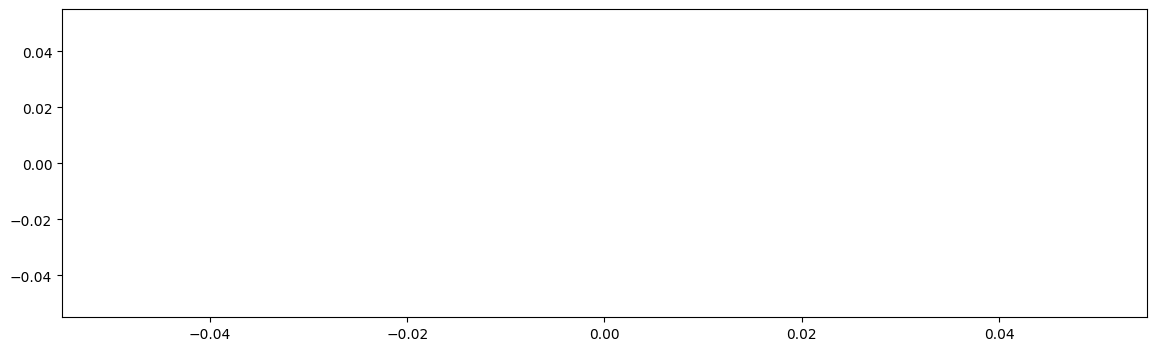

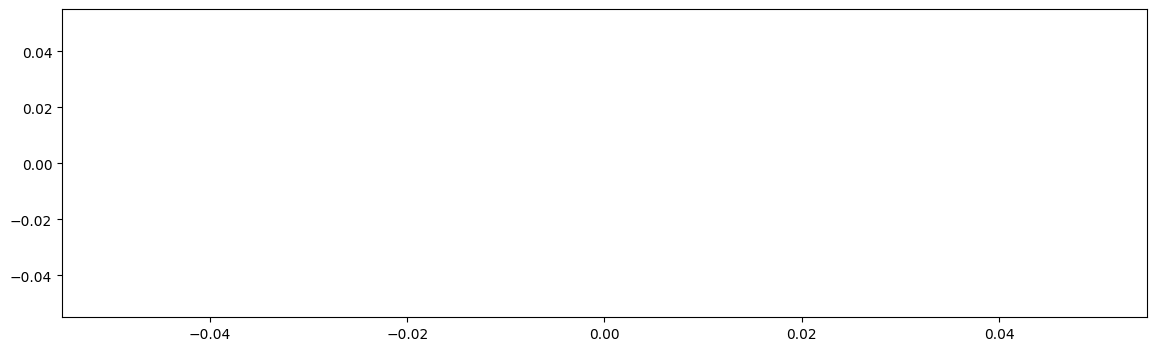

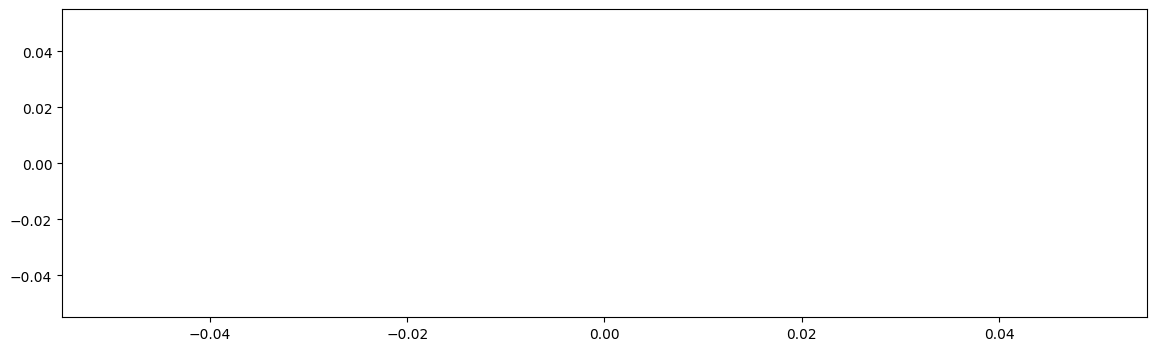

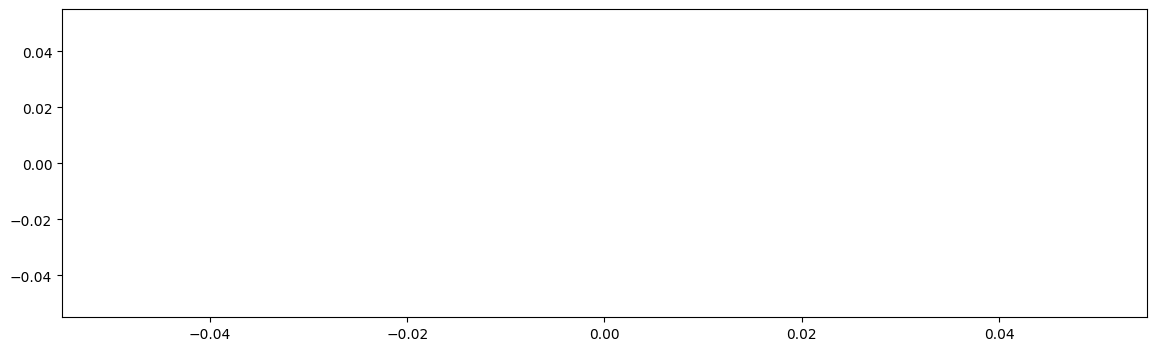

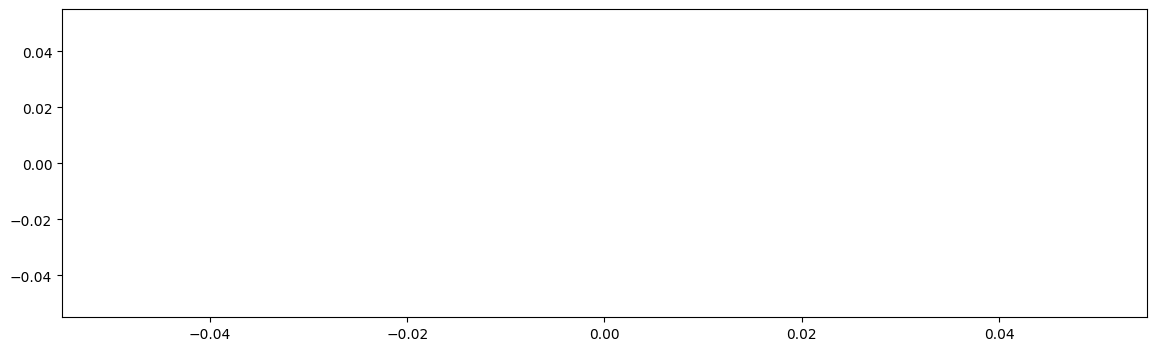

In [ ]:
state   = {'idx': 0}
history = []   # (fname, key, day)
_guard  = False

out      = w.Output()
lbl_info = w.Label()

btn_prev = w.Button(description='◀ Prev')
btn_next = w.Button(description='Next ▶')
dd_file  = w.Dropdown(
    options=[(f.name, i) for i, f in enumerate(data_files)],
    description='File:',
    layout=w.Layout(width='420px'),
)

btn_const = w.ToggleButton(description='CONST', button_style='warning')
btn_bad   = w.ToggleButton(description='BAD',   button_style='danger')
btn_save  = w.Button(description='Save', button_style='success')

day_input   = w.FloatText(description='Day:', step=1.0, layout=w.Layout(width='200px'))
mode_select = w.Dropdown(options=['max', 'min'], description='Type:', layout=w.Layout(width='140px'))
btn_add     = w.Button(description='Add label', button_style='primary')
btn_undo    = w.Button(description='Undo')
btn_reset   = w.Button(description='Reset labels', button_style='danger')


def draw():
    global _guard
    idx   = state['idx']
    fpath = data_files[idx]
    fname = fpath.name
    lbl   = all_labels[fname]

    _guard = True
    dd_file.value   = idx
    btn_const.value = bool(lbl.get('const', False))
    btn_bad.value   = bool(lbl.get('bad',   False))
    _guard = False

    lbl_info.value = f'{idx + 1}/{len(data_files)}: {fname}'

    with out:
        clear_output(wait=True)
        try:
            df = load_file(fpath)
        except Exception as e:
            print(f'Error loading {fname}: {e}')
            return

        is_bad   = bool(lbl.get('bad',   False))
        is_const = bool(lbl.get('const', False))
        bg       = '#fff0f0' if is_bad else '#fff8e1' if is_const else 'white'

        fig, ax = plt.subplots(figsize=(14, 4))
        ax.set_facecolor(bg)

        color = 'salmon' if is_bad else 'steelblue'
        ax.plot(df['day'], df['sind'], '.', color=color, markersize=3, alpha=0.7, rasterized=True)

        span = df['day'].max() - df['day'].min()
        t_s, y_s = gauss_smooth(df['day'].values, df['sind'].values, sigma=span * 0.04)
        ax.plot(t_s, y_s, '-', color='black', lw=1.5, alpha=0.6, zorder=3)

        y_hi = df['sind'].max()
        y_lo = df['sind'].min()
        y_pad = (y_hi - y_lo) * 0.03

        for d in lbl['maxima']:
            ax.axvline(d, color='royalblue', ls='--', lw=1.2, alpha=0.8)
            ax.text(d, y_hi + y_pad, 'MAX', color='royalblue',
                    fontsize=7, ha='center', va='bottom', rotation=90)

        for d in lbl['minima']:
            ax.axvline(d, color='darkorange', ls='--', lw=1.2, alpha=0.8)
            ax.text(d, y_lo - y_pad, 'MIN', color='darkorange',
                    fontsize=7, ha='center', va='top', rotation=90)

        if is_bad:
            ax.text(0.5, 0.5, 'BAD DATA', transform=ax.transAxes,
                    fontsize=28, color='red', alpha=0.3,
                    ha='center', va='center', fontweight='bold')
        elif is_const:
            ax.text(0.5, 0.5, 'CONST', transform=ax.transAxes,
                    fontsize=28, color='#ffb300', alpha=0.4,
                    ha='center', va='center', fontweight='bold')

        tags = ''.join(f' [{t.upper()}]' for t in ('const', 'bad') if lbl.get(t))
        ax.set_title(
            f"{fname}  ({idx + 1}/{len(data_files)}){tags}  |  "
            f"{len(lbl['maxima'])} maxima · {len(lbl['minima'])} minima"
        )
        ax.set_xlabel('Days since first observation')
        ax.set_ylabel('S-index')
        plt.tight_layout()
        plt.show()

        day_input.value = round(float((df['day'].min() + df['day'].max()) / 2), 1)


def go_prev(b):
    if state['idx'] > 0:
        state['idx'] -= 1
        history.clear()
        draw()

def go_next(b):
    if state['idx'] < len(data_files) - 1:
        state['idx'] += 1
        history.clear()
        draw()

def on_dd(change):
    if _guard:
        return
    state['idx'] = change['new']
    history.clear()
    draw()

def on_const(change):
    if _guard:
        return
    all_labels[data_files[state['idx']].name]['const'] = change['new']
    draw()

def on_bad(change):
    if _guard:
        return
    all_labels[data_files[state['idx']].name]['bad'] = change['new']
    draw()

def do_save(b):
    SAVE_PATH.write_text(json.dumps(all_labels, indent=2))
    lbl_info.value = f'Saved to {SAVE_PATH}'

def do_add(b):
    fname = data_files[state['idx']].name
    key   = 'maxima' if mode_select.value == 'max' else 'minima'
    day   = float(day_input.value)
    all_labels[fname][key].append(day)
    history.append((fname, key, day))
    draw()

def do_undo(b):
    if history:
        fname, key, day = history.pop()
        try:
            all_labels[fname][key].remove(day)
        except ValueError:
            pass
        draw()

def do_reset(b):
    fname = data_files[state['idx']].name
    all_labels[fname] = {'maxima': [], 'minima': [], 'const': False, 'bad': False}
    history.clear()
    draw()


btn_prev.on_click(go_prev)
btn_next.on_click(go_next)
dd_file.observe(on_dd, names='value')
btn_const.observe(on_const, names='value')
btn_bad.observe(on_bad, names='value')
btn_save.on_click(do_save)
btn_add.on_click(do_add)
btn_undo.on_click(do_undo)
btn_reset.on_click(do_reset)

display(w.VBox([
    w.HBox([btn_prev, btn_next, dd_file, lbl_info]),
    w.HBox([btn_const, btn_bad, btn_save]),
    w.HBox([day_input, mode_select, btn_add, btn_undo, btn_reset]),
    out,
]))
draw()